RIZKA ULIN NUHA (25031554145)

EKA BERLIA RAHMADANI (25031554109)

# Feature Engineering Teks

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/combined_text_1k_pos_1k_neg.csv')
df = df[['review_id','review','clean_text','rating','sentiment','sentiment_numeric']]
df = df.dropna(subset=['clean_text']).reset_index(drop=True)
df['clean_text'] = df['clean_text'].astype(str).str.strip()
df = df[df['clean_text']!=''].reset_index(drop=True)
print(df.shape)
df.head()

(2000, 6)


,review_id,review,clean_text,rating,sentiment,sentiment_numeric
0,A000044,kalo soal kemeja top dah erigo. 🤝,kalo kemeja top dah erigo,5,Positive,1
1,A000114,"Bahannya adem ya, halus lagi XL ny besar bgtz ...",bahan adem halus bgtz moga pas pakai trimakasi...,5,Positive,1
2,A000202,"Bahannya enak banget, adem. Oversized dikit bu...",bahan enak banget adem oversized dikit,5,Positive,1
3,A000224,bahan adem dan nyaman ini keren sih,bahan adem nyaman keren sih,5,Positive,1
4,A000242,"Tinggi badan 165, berat badan 75, serasa memak...",badan berat badan serasa pakai kemeja oversize...,5,Positive,1


## Eksplorasi singkat

In [3]:
print(df['sentiment'].value_counts())
df['n_kata'] = df['clean_text'].str.split().str.len()
print(df['n_kata'].describe())
print('Duplikat clean_text:', df['clean_text'].duplicated().sum())

sentiment
Positive    1000
Negative    1000
Name: count, dtype: int64
count    2000.000000
mean        8.530000
std         7.831779
min         1.000000
25%         4.000000
50%         6.000000
75%        11.000000
max       103.000000
Name: n_kata, dtype: float64
Duplikat clean_text: 130


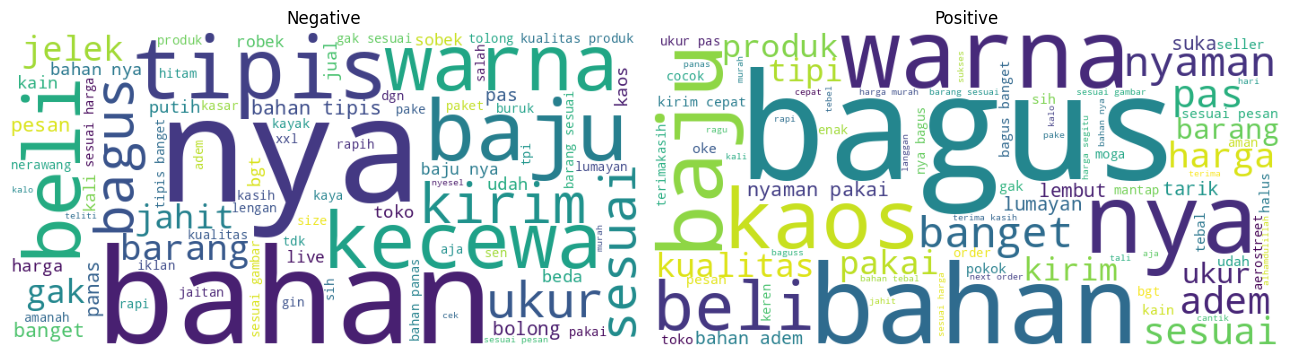

In [4]:
from wordcloud import WordCloud
fig, ax = plt.subplots(1,2, figsize=(13,4))
for a,(lab,g) in zip(ax, df.groupby('sentiment')):
    wc = WordCloud(width=700,height=350,background_color='white',max_words=80).generate(' '.join(g['clean_text']))
    a.imshow(wc); a.axis('off'); a.set_title(lab)
plt.tight_layout(); plt.show()

# Chapter 5 — Feature Engineering Part 1

## 1. One-Hot Encoding (binary Bag of Words)
Setiap kolom = satu kata; nilai 1 jika kata muncul di review, 0 jika tidak.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vec_bin = CountVectorizer(binary=True)
X_bin = vec_bin.fit_transform(df['clean_text'])
df_bin = pd.DataFrame(X_bin.toarray(), columns=vec_bin.get_feature_names_out())
print('Shape:', df_bin.shape)
df_bin.head()

Shape: (2000, 2821)


,aaaaa,aamiin,aamnah,abal,abang,abis,absolutely,abu,abuu,acara,...,ygdiiklanke,ygpanas,yng,you,youpaket,your,yoweslah,yudh,yuk,zonk
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Count Vectorizer (Bag of Words)
Sama seperti one-hot, tetapi nilainya adalah frekuensi kemunculan kata.

In [ ]:
vec_cnt = CountVectorizer()
X_cnt = vec_cnt.fit_transform(df['clean_text'])
df_cnt = pd.DataFrame(X_cnt.toarray(), columns=vec_cnt.get_feature_names_out())
print('Shape:', df_cnt.shape)
df_cnt.head()

Shape: (2000, 2821)


,aaaaa,aamiin,aamnah,abal,abang,abis,absolutely,abu,abuu,acara,...,ygdiiklanke,ygpanas,yng,you,youpaket,your,yoweslah,yudh,yuk,zonk
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


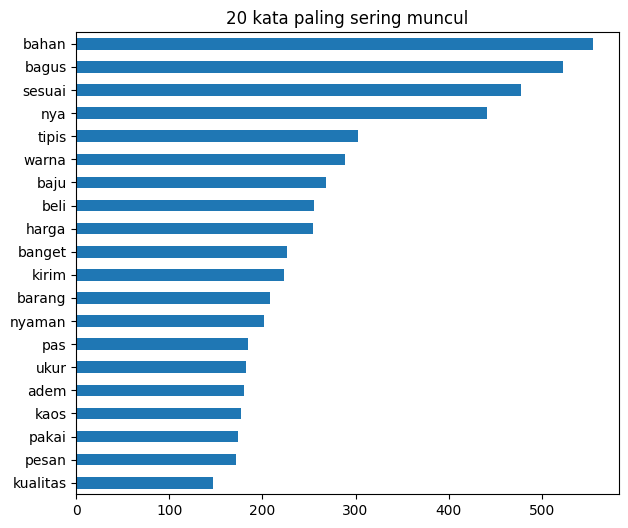

In [ ]:
top = df_cnt.sum().sort_values(ascending=False).head(20)
top[::-1].plot(kind='barh', figsize=(7,6), title='20 kata paling sering muncul')
plt.show()

## 3. TF-IDF

In [ ]:
vec_tfidf = TfidfVectorizer()
X_tfidf = vec_tfidf.fit_transform(df['clean_text'])
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=vec_tfidf.get_feature_names_out())
print('Shape:', df_tfidf.shape)
df_tfidf.head()

Shape: (2000, 2821)


,aaaaa,aamiin,aamnah,abal,abang,abis,absolutely,abu,abuu,acara,...,ygdiiklanke,ygpanas,yng,you,youpaket,your,yoweslah,yudh,yuk,zonk
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Kata dengan bobot TF-IDF rata-rata tertinggi per kelas
for lab in ['Positive','Negative']:
    idx = df.index[df['sentiment']==lab]
    print(lab, '->', df_tfidf.loc[idx].mean().sort_values(ascending=False).head(15).round(3).to_dict())

Positive -> {'bagus': 0.088, 'sesuai': 0.048, 'nyaman': 0.044, 'bahan': 0.042, 'harga': 0.036, 'adem': 0.035, 'pakai': 0.032, 'pas': 0.03, 'banget': 0.028, 'nya': 0.028, 'beli': 0.026, 'warna': 0.026, 'kaos': 0.024, 'pesan': 0.024, 'tarik': 0.023}
Negative -> {'tipis': 0.085, 'bahan': 0.063, 'sesuai': 0.061, 'nya': 0.052, 'baju': 0.035, 'panas': 0.03, 'jelek': 0.029, 'kecewa': 0.029, 'ukur': 0.029, 'warna': 0.029, 'barang': 0.026, 'banget': 0.026, 'bagus': 0.025, 'kirim': 0.024, 'gak': 0.024}


In [ ]:
# Perbandingan ukuran & sparsity ketiga representasi
rows=[]
for name,X in [('One-Hot',X_bin),('Count',X_cnt),('TF-IDF',X_tfidf)]:
    rows.append({'metode':name,'dokumen':X.shape[0],'fitur':X.shape[1],'sparsity_%':round(100*(1-X.nnz/(X.shape[0]*X.shape[1])),2)})
pd.DataFrame(rows)

,metode,dokumen,fitur,sparsity_%
0,One-Hot,2000,2821,99.72
1,Count,2000,2821,99.72
2,TF-IDF,2000,2821,99.72


 we apply it to the result of our preprocessing before

link result of preprocessing:https://drive.google.com/drive/folders/1cEdPrhxMkPfvCVgaJlofTdn61FzC1_Yt?usp=drive_link

In [40]:
import pandas as pd
df = pd.read_csv('/content/hasil prepocesssing 2.csv')
df = df.dropna().reset_index().drop(columns=['index'])
df_pre = df['prepro']
df_pre.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1998 entries, 0 to 1997
Series name: prepro
Non-Null Count  Dtype 
--------------  ----- 
1998 non-null   object
dtypes: object(1)
memory usage: 15.7+ KB


In [41]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_pre)
df_FE = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_FE

,000,10,100,100rb,100rban,10k,11,110,110an,115,...,ygdiiklanke,ygpanas,yh,yng,you,your,yoweslah,yudh,yy,zonk
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.535337,0.0
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


# Chapter 6 — Feature Engineering Part 2

## Tokenisasi
`clean_text` sudah bersih dan dipisah spasi, sehingga tokenisasi cukup dengan `split()` (hasilnya sama dengan `word_tokenize` untuk teks tanpa tanda baca).

In [8]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [12]:
from nltk import word_tokenize
from tqdm import tqdm
sentences = [t.lower().split() for t in df['clean_text']]
sentences[:3]

[['kalo', 'kemeja', 'top', 'dah', 'erigo'],
 ['bahan',
  'adem',
  'halus',
  'bgtz',
  'moga',
  'pas',
  'pakai',
  'trimakasih',
  'erigo',
  'ngecewain'],
 ['bahan', 'enak', 'banget', 'adem', 'oversized', 'dikit']]

## Word2Vec (CBOW)

In [14]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 47.0 MB/s eta 0:00:00


In [15]:
import gensim.models
model = gensim.models.Word2Vec(sentences, min_count=1, vector_size=100, window=5, sg=0, seed=42, workers=1)
w2v = model.wv
print('Vocab:', len(w2v.index_to_key), '| shape vektor:', w2v.vectors.shape)
w2v.index_to_key[:15]

Vocab: 2821 | shape vektor: (2821, 100)


['bahan',
 'bagus',
 'sesuai',
 'nya',
 'tipis',
 'warna',
 'baju',
 'beli',
 'harga',
 'banget',
 'kirim',
 'barang',
 'nyaman',
 'pas',
 'ukur']

In [16]:
model.save('review_produk.w2v')
model = gensim.models.Word2Vec.load('review_produk.w2v')
w2v = model.wv
for kata in ['bahan','kirim','ukur','bagus']:
    if kata in w2v:
        print(kata, '->', [(k, round(s,2)) for k,s in w2v.similar_by_key(kata, topn=5)])

bahan -> [('pakai', 1.0), ('warna', 1.0), ('bagus', 1.0), ('nya', 1.0), ('harga', 1.0)]
kirim -> [('baju', 1.0), ('nya', 1.0), ('beli', 1.0), ('bagus', 1.0), ('pas', 1.0)]
ukur -> [('udah', 1.0), ('banget', 1.0), ('bahan', 1.0), ('warna', 1.0), ('beli', 1.0)]
bagus -> [('pakai', 1.0), ('bahan', 1.0), ('kirim', 1.0), ('harga', 1.0), ('baju', 1.0)]


### Document vector (rata-rata vektor kata)
Review yang semua katanya tidak ada di vocab diberi vektor nol agar tidak error (di materi baris ini dikomentari).

In [17]:
def get_document_vector(tokens, wv, dim):
    vecs = [wv[w] for w in tokens if w in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v = np.array([get_document_vector(s, w2v, model.vector_size) for s in sentences])
print(X_w2v.shape)
pd.DataFrame(X_w2v).head()

(2000, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.120392,-0.021904,0.022682,0.023976,-0.033122,0.116537,0.052784,0.080397,-0.093758,0.042509,...,-0.158471,0.139823,0.031977,-0.066948,0.127027,-0.082343,0.006518,0.032323,-0.092914,-0.056276
1,0.200862,-0.032094,0.046453,0.044124,-0.055094,0.200954,0.095566,0.135502,-0.150411,0.063185,...,-0.266674,0.229346,0.046635,-0.110779,0.212787,-0.136974,0.013593,0.052516,-0.148571,-0.096942
2,0.206597,-0.037533,0.046868,0.049712,-0.059429,0.207933,0.099436,0.141687,-0.158300,0.061266,...,-0.281625,0.244231,0.048499,-0.118622,0.223232,-0.142936,0.013343,0.053300,-0.150875,-0.097956
3,0.285220,-0.043857,0.066429,0.065287,-0.079763,0.288421,0.135246,0.195148,-0.218420,0.091314,...,-0.384707,0.333773,0.066283,-0.161399,0.313635,-0.196457,0.016056,0.077027,-0.214551,-0.141686
4,0.189215,-0.033584,0.040571,0.040532,-0.054936,0.187734,0.091002,0.129892,-0.141804,0.056470,...,-0.254831,0.216456,0.044246,-0.104863,0.201569,-0.130890,0.012438,0.049573,-0.140184,-0.087299


### Visualisasi UMAP — Word2Vec
Hanya 150 kata teratas supaya label terbaca.

In [19]:
!pip install umap-learn

In [20]:
from umap import UMAP
import plotly.express as px

def plot_umap(wv, title, n=150):
    vecs = wv.vectors[:n]
    emb = UMAP(random_state=42, n_neighbors=10).fit_transform(vecs)
    d = pd.DataFrame(emb, columns=['umap1','umap2']); d['word'] = wv.index_to_key[:n]
    fig = px.scatter(d, x='umap1', y='umap2', text='word', title=title)
    fig.update_traces(textposition='top center')
    fig.update_layout(height=700)
    return fig

plot_umap(w2v, 'Word2Vec Visualization').show()

## FastText (Skip-Gram)

In [21]:
model_ft = gensim.models.FastText(sentences, min_count=1, vector_size=100, window=5, min_n=3, max_n=6, sg=1, epochs=10, seed=42, workers=1)
ft = model_ft.wv
model_ft.save('review_produk.fasttext')
model_ft = gensim.models.FastText.load('review_produk.fasttext')   # di materi memakai Word2Vec.load, yang kurang tepat untuk FastText
ft = model_ft.wv
print('Vocab:', len(ft.index_to_key), '| shape vektor:', ft.vectors.shape)
for kata in ['bahan','kirim','ukur','bagus']:
    if kata in ft:
        print(kata, '->', [(k, round(s,2)) for k,s in ft.similar_by_key(kata, topn=5)])

Vocab: 2821 | shape vektor: (2821, 100)
bahan -> [('bahanx', 1.0), ('bahany', 1.0), ('nya', 1.0), ('adem', 1.0), ('bahas', 0.99)]
kirim -> [('cepatseller', 1.0), ('cepatt', 1.0), ('kirimmm', 1.0), ('terimakasiiii', 1.0), ('seller', 1.0)]
ukur -> [('ukuean', 1.0), ('padan', 1.0), ('bdan', 1.0), ('berat', 1.0), ('badantidak', 1.0)]
bagus -> [('bagusbahan', 1.0), ('bahas', 1.0), ('bahu', 1.0), ('bangetbahan', 1.0), ('dnbahan', 1.0)]


In [22]:
# Keunggulan FastText: kata yang tidak ada di vocab tetap punya vektor (lewat character n-gram)
kata_oov = 'bahannyaaa'
print('di vocab W2V   :', kata_oov in w2v)
print('di vocab FastText:', kata_oov in ft.key_to_index, '| tapi vektor tersedia:', ft[kata_oov].shape)
print('Terdekat:', ft.similar_by_vector(ft[kata_oov], topn=5))

di vocab W2V   : False
di vocab FastText: False | tapi vektor tersedia: (100,)
Terdekat: [('bgusbahanya', 0.9999537467956543), ('bahannyaa', 0.9999398589134216), ('enggabahan', 0.9999368786811829), ('bahnnya', 0.9999150633811951), ('baguscocok', 0.9998681545257568)]


In [23]:
X_ft = np.array([get_document_vector(s, ft, model_ft.vector_size) for s in sentences])
print(X_ft.shape)
pd.DataFrame(X_ft).head()

(2000, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.075676,-0.014810,0.207457,0.157591,0.272710,0.391794,0.182315,0.068847,-0.094279,-0.012956,...,0.271239,-0.080725,0.144223,0.048515,0.245199,0.111740,-0.195720,0.195810,-0.240246,0.084905
1,-0.083909,-0.019819,0.190978,0.168531,0.250554,0.378397,0.174489,0.051632,-0.104170,-0.000843,...,0.277055,-0.089396,0.152129,0.041138,0.233687,0.095214,-0.171275,0.155341,-0.218059,0.069766
2,-0.093861,-0.018190,0.200797,0.183439,0.264944,0.439528,0.198645,0.043696,-0.112104,0.005313,...,0.302819,-0.099622,0.161848,0.045273,0.244526,0.082308,-0.172805,0.168230,-0.231360,0.095351
3,-0.104081,-0.030371,0.205383,0.195172,0.270501,0.431734,0.196842,0.053985,-0.122726,0.006868,...,0.315454,-0.104115,0.170460,0.045589,0.257332,0.091287,-0.176106,0.164791,-0.239622,0.081198
4,-0.091265,-0.024771,0.214614,0.175613,0.273810,0.427695,0.197166,0.051662,-0.115995,0.002365,...,0.297838,-0.091368,0.159448,0.052835,0.251199,0.089340,-0.187247,0.179809,-0.247157,0.091653


In [24]:
plot_umap(ft, 'FastText Visualization').show()

## Tuning: epoch lebih banyak
Dengan parameter default materi (Word2Vec 5 epoch, `min_count=1`), korpus 2.000 review pendek ini belum cukup terlatih: hampir semua kata punya kemiripan ≈1.0 satu sama lain. Di sini dilatih ulang dengan `epochs=100` dan `min_count=2` (kata yang hanya muncul sekali dibuang).

In [25]:
w2v_t = gensim.models.Word2Vec(sentences, min_count=2, vector_size=100, window=5, sg=0, epochs=100, seed=42, workers=1)
ft_t = gensim.models.FastText(sentences, min_count=2, vector_size=100, window=5, min_n=3, max_n=6, sg=1, epochs=100, seed=42, workers=1)
print('Vocab W2V tuned:', len(w2v_t.wv.index_to_key))
for nm,m in [('Word2Vec',w2v_t.wv),('FastText',ft_t.wv)]:
    print('==',nm)
    for kata in ['bahan','kirim','ukur','bagus','tipis']:
        if kata in m: print(kata,'->',[(k,round(sc,2)) for k,sc in m.similar_by_key(kata,topn=5)])

Vocab W2V tuned: 1094
== Word2Vec
bahan -> [('bahanya', 0.57), ('kain', 0.53), ('combed', 0.53), ('strechy', 0.52), ('tebal', 0.5)]
kirim -> [('dipacking', 0.59), ('telat', 0.58), ('aman', 0.57), ('estimasi', 0.57), ('takut', 0.56)]
ukur -> [('berat', 0.64), ('kecil', 0.62), ('size', 0.6), ('sweatshirt', 0.6), ('laki', 0.6)]
bagus -> [('desain', 0.53), ('ngecewain', 0.53), ('halus', 0.53), ('strechy', 0.52), ('kerennn', 0.5)]
tipis -> [('kirain', 0.64), ('tipiss', 0.63), ('nrawang', 0.6), ('partai', 0.56), ('tera', 0.54)]
== FastText
bahan -> [('bahanx', 0.81), ('bahany', 0.68), ('bagusbahan', 0.64), ('bahanya', 0.63), ('bahanny', 0.6)]
kirim -> [('ngirim', 0.54), ('kiri', 0.51), ('smpe', 0.48), ('habis', 0.48), ('cepat', 0.47)]
ukur -> [('kur', 0.57), ('gajelas', 0.52), ('laki', 0.49), ('serasa', 0.48), ('lingkar', 0.48)]
bagus -> [('baguss', 0.63), ('bagusss', 0.6), ('bagusbahan', 0.59), ('baguuss', 0.56), ('bagi', 0.44)]
tipis -> [('tipiss', 0.78), ('tipisss', 0.75), ('tipissss', 0.

In [26]:
X_w2v_t = np.array([get_document_vector(s, w2v_t.wv, 100) for s in sentences])
X_ft_t = np.array([get_document_vector(s, ft_t.wv, 100) for s in sentences])
plot_umap(w2v_t.wv, 'Word2Vec (tuned) Visualization').show()

In [27]:
plot_umap(ft_t.wv, 'FastText (tuned) Visualization').show()

# Analisis hasil (Exercise 5)
Untuk membandingkan kualitas fitur secara objektif, tiap representasi dipakai melatih model klasifikasi sentimen yang sama (Logistic Regression) dengan cross-validation 5-fold.

In [29]:
!pip install scikit-learn

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
vec_cnt = CountVectorizer()
X_cnt = vec_cnt.fit_transform(df['clean_text'])

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Memastikan X_tfidf terdefinisi
if 'X_tfidf' not in globals():
    vec_tfidf = TfidfVectorizer()
    X_tfidf = vec_tfidf.fit_transform(df['clean_text'])

y = df['sentiment_numeric'].values
cv = StratifiedKFold(5, shuffle=True, random_state=42)
features = {'One-Hot':X_bin,'Count':X_cnt,'TF-IDF':X_tfidf,'Word2Vec (CBOW)':X_w2v,'FastText (SG)':X_ft,'Word2Vec (tuned)':X_w2v_t,'FastText (tuned)':X_ft_t}
res=[]
for n,X in features.items():
    s = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=cv, scoring='f1')
    res.append({'fitur':n,'dimensi':X.shape[1],'F1 rata-rata':round(s.mean(),4),'std':round(s.std(),4)})
res = pd.DataFrame(res).sort_values('F1 rata-rata', ascending=False)
res

,fitur,dimensi,F1 rata-rata,std
2,TF-IDF,2821,0.8647,0.0102
1,Count,2821,0.8628,0.0177
0,One-Hot,2821,0.8621,0.0136
5,Word2Vec (tuned),100,0.8569,0.0168
6,FastText (tuned),100,0.8540,0.0155
4,FastText (SG),100,0.6522,0.0214
3,Word2Vec (CBOW),100,0.5619,0.0350


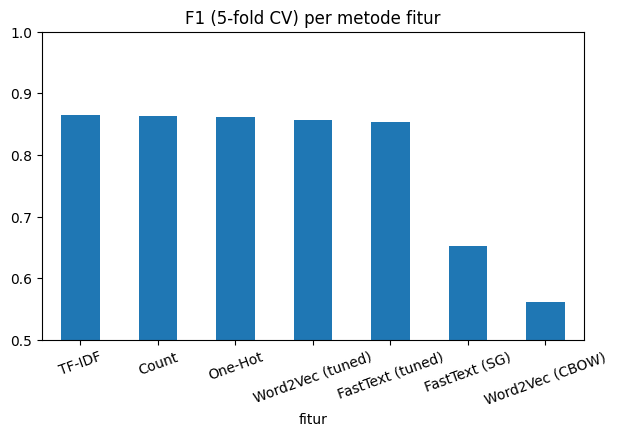

In [39]:
res.set_index('fitur')['F1 rata-rata'].plot(kind='bar', ylim=(0.5,1), figsize=(7,4), title='F1 (5-fold CV) per metode fitur')
plt.xticks(rotation=20); plt.show()